<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# DATA/MSML 641: Natural Language Processing
## Lecture 5: Vector Semantics and Embeddings

**University of Maryland, College Park**  
**Spring 2026**  
**Instructor**: Armin Mehrabian  
**Date**: March 3–4, 2026  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Introduction

*Nets are for fish;*  
*Once you get the fish, you can forget the net.*  
*Words are for meaning;*  
*Once you get the meaning, you can forget the words*

— **Zhuangzi (庄子)**, Chapter 26

# Distributional Hypothesis

**Definition** – Words that occur in similar contexts tend to have similar meanings. The link between how words are distributed and the similarity in what they mean is called the **distributional hypothesis**.

- Formulated by linguists like Joos (1950), Harris (1954), and Firth (1957)

**Examples:**
- Eye-doctor & Oculist → near words are *eye* or *examined*

# Lexical Semantic – Lemmas and Senses (1/6)

**Mouse** (N)
1. any of numerous small rodents...
2. a hand-operated device that controls a cursor...

**Mouse** is lemma for: **Mice** and **Mouse**

**Word sense**: each of the aspects of the meaning of a word is called **word sense**

# Lexical Semantic – Synonym (2/6)

**Synonym** – when one sense of a word is identical or near identical to one sense in another word then these two words are synonyms.

- couch/sofa
- vomit/throw up
- filbert/hazelnut
- car/automobile
- H₂O/water

# Lexical Semantic – Word Similarity (3/6)

**Word Similarity** – words may not have so many synonyms but certainly have similar words.
- Cat and Dog are similar words

**Manual Annotation of Similarity** (SimLex-999 dataset, Hill et. Al 2015)

| Word 1 | Word 2 | Score |
|--------|--------|-------|
| vanish | disappear | 9.8 |
| belief | impression | 5.95 |
| muscle | bone | 3.65 |
| modest | flexible | 0.98 |
| hole | agreement | 0.3 |

source: https://fh295.github.io/simlex.html

# Lexical Semantic – Word Relatedness (4/6)

**Word relatedness** or association in psychology – two words are co-participating in an event or are related eventively. A common way that words can be related is through the same **semantic field**, which is a set of words that cover a particular semantic domain and bear structured relations with each other.

- **Co-participation**: cup and coffee
- **Related Eventively**: Scalpel and Surgeon
- **Semantic Field**:
  - field of **hospitals**: surgeon, scalpel, nurse, anesthetic, hospital
  - Field of **restaurants**: waiter, menu, plate, food, chef

# Lexical Semantic – Semantic Frames and Roles (5/6)

**Semantic Frames** – closely related to semantic fields is semantic frames. A semantic frame is a set of words that denote perspectives or participants in a particular type of event.

- **buy** (the event from the perspective of the buyer)
- **sell** (from the perspective of the seller)
- **pay** (focusing on the monetary aspect)

**Paraphrasing Task:**
- *Sam bought the book from Ling* (Paraphrase to) *Ling sold the book to Sam*

# Lexical Semantic – Connotation (6/6)

**Connotation** - Words have affective meanings or connotations. The word connotation has different meanings in different fields, but here we use it to mean the aspects of a word's meaning that are related to a writer or reader's emotions, sentiments, opinions, or evaluations.

- Pos-connotation: *wonderful*; Neg-connotation: *dreary*
- A mix of Pos-conn and Neg-conn of words with the same meaning
  - *copy, replica, reproduction*
- Pos-evaluation: *great, love*; Neg-evaluation: *hate, terrible*
- Words are different in 3 dimensions of affect (Osgood 1957):
  - **valence**: the pleasantness of the stimulus
  - **arousal**: the intensity of emotion provoked by the stimulus
  - **dominance**: the degree of control exerted by the stimulus

# Vector Semantic

*Ongchoi is delicious sauteed with garlic.*  
*Ongchoi is superb over rice.*  
*... ongchoi leaves with salty sauces ...*

And suppose that you had seen many of these context words in other contexts:

*... spinach sauteed with garlic over rice ...*  
*... chard stems and leaves are delicious ...*  
*... collard greens and other salty leafy greens*

<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 1. Sparse Vector Representation



# Words and Vectors

**Vectors** or the **Distributional model** of word meaning is based on a co-occurrence matrix, a way to represent how often two words co-occur. Two popular matrices:

- **Term-document co-occurrence matrix**
- **Term-term co-occurrence matrix**

## Term–Document Co-occurrence Matrix  
Example:  
Two docs →  
- Doc1: *I like NLP*  
- Doc2: *NLP is fun*

| Term | Doc1 | Doc2 |
|------|------|------|
| I    | 1 | 0 |
| like | 1 | 0 |
| NLP  | 1 | 1 |
| is   | 0 | 1 |
| fun  | 0 | 1 |

Each word is a vector of document frequencies.

## Term–Term Co-occurrence Matrix  
Example text: *I like NLP. NLP is fun.*

|     | I | like | NLP | is | fun |
|-----|---|------|-----|----|-----|
| I   | 0 | 1 | 1 | 0 | 0 |
| like| 1 | 0 | 1 | 0 | 0 |
| NLP | 1 | 1 | 0 | 1 | 1 |
| is  | 0 | 0 | 1 | 0 | 1 |
| fun | 0 | 0 | 1 | 1 | 0 |

Each word is represented by how often it appears near others.

# Words and Vectors

4 documents from Shakespeare's plays and 4 words

- **Vector** – a list or array of numbers
- Julius Caesar -> [7, 62, 1, 2]

In [5]:
# Term-document matrix example from Shakespeare's plays
shakespeare_matrix = pd.DataFrame({
    'As You Like It': [1, 114, 36, 20],
    'Twelfth Night': [0, 80, 58, 15],
    'Julius Caesar': [7, 62, 1, 2],
    'Henry V': [13, 89, 4, 3]
}, index=['battle', 'good', 'fool', 'wit'])

print("Term-Document Matrix (Shakespeare's Plays)")
print("="*60)
print(shakespeare_matrix)
print("\nColumn vector for 'Julius Caesar':")
print(shakespeare_matrix['Julius Caesar'].values)

Term-Document Matrix (Shakespeare's Plays)
        As You Like It  Twelfth Night  Julius Caesar  Henry V
battle               1              0              7       13
good               114             80             62       89
fool                36             58              1        4
wit                 20             15              2        3

Column vector for 'Julius Caesar':
[ 7 62  1  2]


# Visualizing Word Vectors

Word embeddings can be projected into a lower dimensinal space such as 2D using **t-SNE** to visualize semantic relationships between words.

<p align="center">
  <img src="img/tsne_vector_semantics.png" width="90%">
</p>


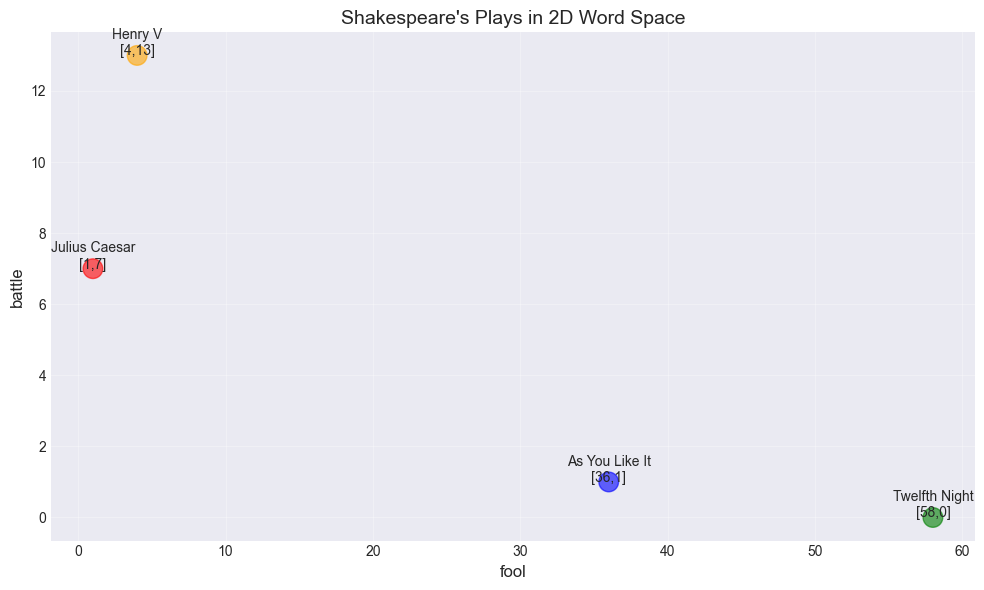

In [9]:
# Visualize documents in 2D space (using 'fool' and 'battle' dimensions)
fig, ax = plt.subplots(figsize=(10, 6))

x_coords = shakespeare_matrix.loc['fool'].values
y_coords = shakespeare_matrix.loc['battle'].values
labels = shakespeare_matrix.columns

ax.scatter(x_coords, y_coords, s=200, alpha=0.6, c=['blue', 'green', 'red', 'orange'])

for i, label in enumerate(labels):
    ax.annotate(f"{label}\n[{x_coords[i]},{y_coords[i]}]", 
                (x_coords[i], y_coords[i]),
                fontsize=10, ha='center')

ax.set_xlabel('fool', fontsize=12)
ax.set_ylabel('battle', fontsize=12)
ax.set_title("Shakespeare's Plays in 2D Word Space", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Words as vectors: document dimensions

The term-document matrix for four words in four Shakespeare plays. The red boxes show that each word is represented as a row vector of length four.

**Battle** -> [1, 0, 7, 13]

In [10]:
# Extract row vectors (words as vectors in document space)
print("Words as Vectors (Document Dimensions)")
print("="*60)
for word in shakespeare_matrix.index:
    vec = shakespeare_matrix.loc[word].values
    print(f"{word:10} -> {vec}")

Words as Vectors (Document Dimensions)
battle     -> [ 1  0  7 13]
good       -> [114  80  62  89]
fool       -> [36 58  1  4]
wit        -> [20 15  2  3]


# Words as vectors: word dimensions (1/3)

**Context window size ±4 words around each word**

- is traditionally followed by **cherry** pie, traditional dessert
- often mixed, such as **strawberry** rhubarb pie, Apple pie
- computer peripherals and personal **digital** assistants, These devices usually
- a computer. This includes **information** available on the internet

# Words as vectors: word dimensions (2/3)

Co-occurrence vectors for 4 words in Wikipedia Corpus, showing six of the dimensions.

| Word | aardvark | ... | computer | data | result | pie | sugar | ... |
|------|----------|-----|----------|------|--------|-----|-------|-----|
| cherry | 0 | ... | 2 | 8 | 9 | 442 | 25 | ... |
| strawberry | 0 | ... | 0 | 0 | 1 | 60 | 19 | ... |
| **digital** | **0** | **...** | **1670** | **1683** | **85** | **5** | **4** | **...** |
| information | 0 | ... | 3325 | 3982 | 378 | 5 | 13 | ... |

# Words as vectors: word dimensions (3/3)

A spatial visualization of word vectors for **digital** and **information**, showing just two of the dimensions, corresponding to the words **data** and **computer**.

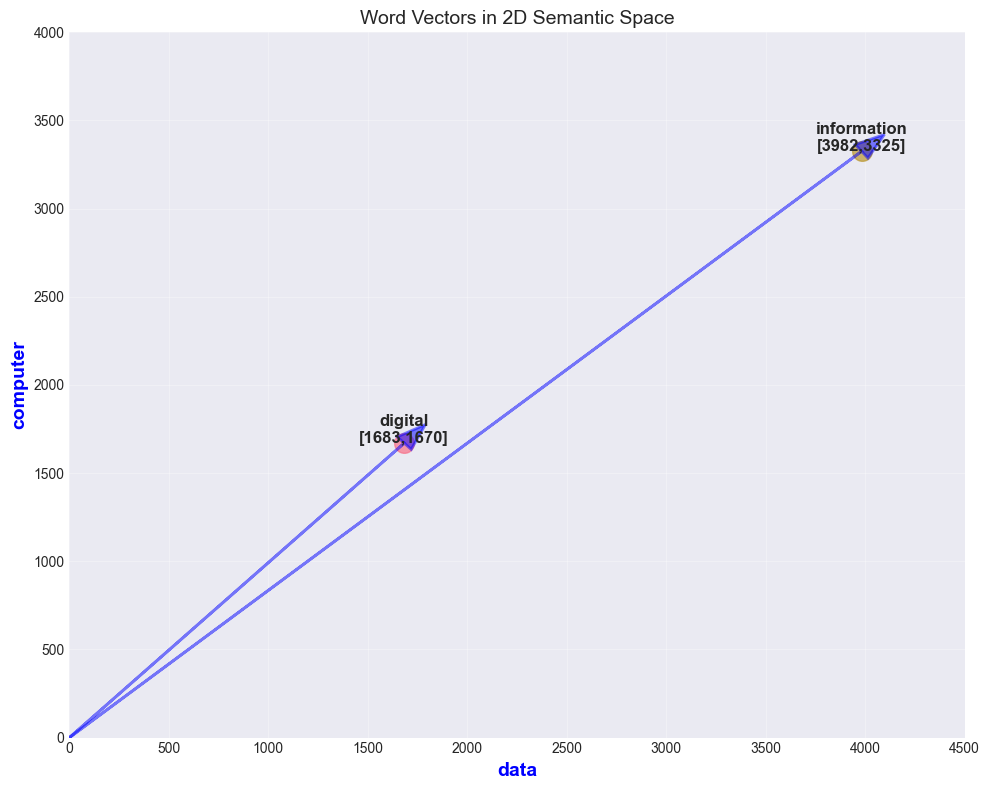

In [12]:
# Simulate word vectors in 2D space (data vs computer dimensions)
word_vectors_2d = {
    'digital': [1683, 1670],
    'information': [3982, 3325]
}

fig, ax = plt.subplots(figsize=(10, 8))

for word, coords in word_vectors_2d.items():
    ax.scatter(coords[0], coords[1], s=200, alpha=0.7)
    ax.annotate(f"{word}\n[{coords[0]},{coords[1]}]", 
                coords, fontsize=12, ha='center', fontweight='bold')
    # Draw arrow from origin
    ax.arrow(0, 0, coords[0], coords[1], head_width=100, head_length=150, 
             fc='blue', ec='blue', alpha=0.5, linewidth=2)

ax.set_xlabel('data', fontsize=14, fontweight='bold', color='blue')
ax.set_ylabel('computer', fontsize=14, fontweight='bold', color='blue')
ax.set_title('Word Vectors in 2D Semantic Space', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 4500)
ax.set_ylim(0, 4000)
plt.tight_layout()
plt.show()

# Cosine for Measuring Similarity (1/2)

**Vector Length:**
$$|\mathbf{v}| = \sqrt{\sum_{i=1}^{N} v_i^2}$$

**Normalized dot product:**
$$\frac{\mathbf{a} \cdot \mathbf{b}}{|\mathbf{a}||\mathbf{b}|} = \cos\theta$$

**Cosine Similarity:**
$$\text{cosine}(\mathbf{v},\mathbf{w}) = \frac{\mathbf{v} \cdot \mathbf{w}}{|\mathbf{v}||\mathbf{w}|} = \frac{\sum_{i=1}^{N} v_i w_i}{\sqrt{\sum_{i=1}^{N} v_i^2} \sqrt{\sum_{i=1}^{N} w_i^2}}$$

# Cosine for Measuring Similarity (2/2)

A (rough) graphical demonstration of cosine similarity, showing vectors for three words (*cherry*, *digital*, and *information*) in the two-dimensional space defined by counts of the words *computer* and *pie* nearby.


In [14]:
# Cosine similarity demonstration
def cosine_sim(v1, v2):
    """Calculate cosine similarity between two vectors"""
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

# Example vectors (pie, data, computer dimensions)
cherry = np.array([442, 8, 2])
digital = np.array([5, 1683, 1670])
information = np.array([5, 3982, 3325])

print("Cosine Similarity Examples")
print("="*60)
print(f"cherry vector:      {cherry}")
print(f"digital vector:     {digital}")
print(f"information vector: {information}")
print()
print(f"cos(cherry, information) = {cosine_sim(cherry, information):.3f}")
print(f"cos(digital, information) = {cosine_sim(digital, information):.3f}")
print(f"cos(cherry, digital) = {cosine_sim(cherry, digital):.3f}")

Cosine Similarity Examples
cherry vector:      [442   8   2]
digital vector:     [   5 1683 1670]
information vector: [   5 3982 3325]

cos(cherry, information) = 0.018
cos(digital, information) = 0.996
cos(cherry, digital) = 0.018


### Understanding TF–IDF Components

**1. Term Frequency (TF)**  
$\text{tf}_{t,d} = \text{count}(t,d)$  
Counts how often a term *t* appears in a document *d*.  
A higher count → the word is more important *within that document.*

---

**2. Log-scaled Term Frequency**  
$\text{tf}_{t,d} = 1 + \log_{10}(\text{count}(t,d))$  
Raw counts can be dominated by very frequent words (“the”, “data”).  
Using a log reduces the impact of large counts and keeps zero counts as 0.

---

**3. Document Frequency (DF) and Inverse Document Frequency (IDF)**  
$\text{idf}_t = \log_{10}\left(\frac{N}{\text{df}_t}\right)$  
- $\text{df}_t$: number of documents containing term *t*  
- *N*: total number of documents  

Common words appear in many documents → smaller IDF.  
Rare words → higher IDF → more informative.

---

**4. TF–IDF Weight**  
$w_{t,d} = \text{tf}_{t,d} \times \text{idf}_t$  
Combines local importance (TF) and global rarity (IDF).  
Gives high weight to words that are **frequent in one document but rare overall.**

---

**Example:**  
In a news corpus,  
- “economy” → frequent in business articles but rare elsewhere → high TF-IDF.  
- “the” → frequent everywhere → low TF-IDF.


# TF-IDF: Weighing terms in the vector

A tf-idf weighted term-document matrix for four words in four Shakespeare plays, using the counts.

| Word | As You Like It | Twelfth Night | Julius Caesar | Henry V |
|------|----------------|---------------|---------------|----------|
| battle | 0.246 | 0 | 0.454 | 0.520 |
| good | 0 | 0 | 0 | 0 |
| fool | 0.030 | 0.033 | 0.0012 | 0.0019 |
| wit | 0.085 | 0.081 | 0.048 | 0.054 |

In [16]:
# TF-IDF implementation
from sklearn.feature_extraction.text import TfidfTransformer

# Calculate TF-IDF from the Shakespeare matrix
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(shakespeare_matrix.T).T

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=shakespeare_matrix.index,
    columns=shakespeare_matrix.columns
)

print("TF-IDF Weighted Term-Document Matrix")
print("="*60)
print(tfidf_df.round(3))

TF-IDF Weighted Term-Document Matrix
        As You Like It  Twelfth Night  Julius Caesar  Henry V
battle           0.010           0.00          0.137    0.176
good             0.940           0.80          0.990    0.983
fool             0.297           0.58          0.016    0.044
wit              0.165           0.15          0.032    0.033


<div style="text-align: left; margin-bottom: 20px;">
  <img src="https://umd-brand.transforms.svdcdn.com/production/uploads/images/logos-primary.jpg?w=1801&h=601&auto=compress%2Cformat&fit=crop&dm=1613775207&s=71ce45031f9164cb409f11a2e28d8b8c" 
       alt="UMD Logo" style="max-width: 300px; height: auto;" />
</div>

# PART 2. Dense Vector Representation



# Model for Dense Vector Representation

- **Documents** = {"This is an example", "This is another example"}
- **Vocabulary** = {this, is, an, another, example}

• For a window size of 1, the surrounding words around "*is*" in the first document are "*this*" and "*an*"

• We can build a binary classifier for pairs *(input word, output word)* such that
  - The pairs **(is, this)** and **(is, an)** are classified as **true** (neighboring words)
  - The pairs **(is, example)** and **(is, another)** are classified as **false**

• Let $\mathbf{w}_i = [w_{i1}, w_{i2}, ..., w_{iD}]$ be the vector representation of word *i* in *D*-dimension

```
w_is  -----> Classification -----> 1
w_this ----> Model

w_is  -----> Classification -----> 0
w_another -> Model
```

• Neural network can be used to train $\mathbf{w}_i$

<p align="center">
  <img src="img/word2vec_fasttext.png" width="90%">
</p>

# Word2Vec Neural Network Architecture


<p align="center">
  <img src="img/word2vec_architecture.png" width="60%">
</p>

**Input Layer:**
- **Input Vector**: One-hot encoded (vocabulary size of 10,000)
- A '1' in the position corresponding to the word "great"

**Hidden Layer:**
- **Linear Neurons** (Dimension of 300)
- 300 neurons

**Output Layer:**
- **Softmax Classifier**
- 10,000 neurons
- Probability that the word at a randomly chosen, nearby position is "abandon"
- ... "ability"
- ... "able"
- ... "zone"

# Word2Vec Learning Models


<p align="center">
  <img src="img/cbow_skipgram.png" width="70%">
</p>

## Continuous Bag of Words (CBOW):
• Given the context predict the word:
  - $w_{i-2}, w_{i-1}, \mathbf{w}_i, w_{i+1}, w_{i+2}$
• Example: **The cat ate ______.**
  - Fill in the blank, e.g. "food".
• Faster to train
• Works well for large amount of training data

## Continuous Skip-Gram:
• Given the word predict the context:
  - $w_{i-2}, w_{i-1}, \mathbf{w}_i, w_{i+1}, w_{i+2}$
• Ex: ____ ____ ____ food.
  - Fill in the blank, e.g. "The cat ate"
• Slower to train
• Works better for infrequent words

# Word2Vec: CBOW Example


• **"the cat ___ on floor"**

<p align="center">
  <img src="img/cbow_example.png" width="70%">
</p>

**Input layer:**
- the, cat, on, floor (one-hot vectors)

**Hidden layer:**
- $W_{V \times N}$ (V-dim to N-dim)
- N-dim hidden representation

**Output layer:**
- $W'_{N \times V}$ (N-dim to V-dim)
- V-dim output
- Predicts: **sat**

**We must learn W and W'**

**N will be the size of word vector**

# Semantic Properties of Embeddings

**Relational properties of the GloVe vector space**, shown by projecting vectors onto two dimensions.

<p align="center">
  <img src="img/semantic_math.png" width="70%">
</p>

**(a)** *king* - *man* + *woman* is close to *queen*.

**(b)** offsets seem to capture comparative and superlative morphology.


*(Pennington et al., 2014)*

In [22]:
# Demonstrate word embeddings using a simple corpus
from gensim.models import Word2Vec
import nltk

# Sample corpus
sentences = [
    ['king', 'is', 'a', 'strong', 'man'],
    ['queen', 'is', 'a', 'wise', 'woman'],
    ['boy', 'is', 'a', 'young', 'man'],
    ['girl', 'is', 'a', 'young', 'woman'],
    ['prince', 'is', 'a', 'young', 'king'],
    ['princess', 'is', 'a', 'young', 'queen'],
    ['man', 'is', 'strong'],
    ['woman', 'is', 'pretty'],
    ['prince', 'is', 'a', 'boy', 'will', 'be', 'king'],
    ['princess', 'is', 'a', 'girl', 'will', 'be', 'queen']
]

# Train Word2Vec model
model = Word2Vec(sentences, vector_size=50, window=3, min_count=1, workers=4, epochs=100)

# Test semantic relationships
print("Word2Vec Semantic Properties")
print("="*60)

try:
    result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
    print("\nAnalogy: king - man + woman ≈ ?")
    for word, score in result:
        print(f"  {word}: {score:.3f}")
except:
    print("\nAnalogy: (need larger corpus for reliable analogies)")


Word2Vec Semantic Properties

Analogy: king - man + woman ≈ ?
  prince: 0.153
  be: 0.098
  boy: 0.053


In [29]:
# Demonstrate word embeddings using Reuters corpus (fixed version)
from gensim.models import Word2Vec
import nltk
from nltk.corpus import reuters

# Download required NLTK resources
nltk.download('reuters')
nltk.download('punkt')       # sentence tokenizer
nltk.download('punkt_tab')   # punkt tables needed for reuters.sents()

# Load all sentences into memory (thread-safe)
sentences = list(reuters.sents())
print(f"Loaded {len(sentences)} sentences.")

# Train Word2Vec model
model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,       # skip-gram for better semantics
    epochs=20
)

# Word2Vec trained on Reuters — print semantic examples and embeddings
from pprint import pprint

# Check available vocabulary size
print(f"Vocabulary size: {len(model.wv.index_to_key)}")

# Show words most similar to 'market'
print("\nMost similar to 'market':")
pprint(model.wv.most_similar('market', topn=5))

# Analogy within Reuters domain
# e.g., "oil" - "energy" + "bank" ≈ ?
try:
    print("\nAnalogy: oil - energy + bank ≈ ?")
    result = model.wv.most_similar(positive=['oil', 'bank'], negative=['energy'], topn=5)
    pprint(result)
except KeyError:
    print("Analogy failed — some words not in corpus.")

# Show a sample embedding for one word
word = 'market'
print(f"\nEmbedding for '{word}' (first 10 dimensions):")
print(model.wv[word][:10])



[nltk_data] Downloading package reuters to
[nltk_data]     /Users/amehrabi/nltk_data...
[nltk_data]   Package reuters is already up-to-date!
[nltk_data] Downloading package punkt to /Users/amehrabi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/amehrabi/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Loaded 54716 sentences.


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 19769

Most similar to 'market':
[('markets', 0.7235547304153442),
 ('pacemaker', 0.6584956049919128),
 ('plunging', 0.6229670643806458),
 ('bullish', 0.6154537796974182),
 ('bias', 0.6091126203536987)]

Analogy: oil - energy + bank ≈ ?
[('central', 0.6667110323905945),
 ('banks', 0.5503009557723999),
 ('outright', 0.5183268785476685),
 ('Bank', 0.5115377902984619),
 ('Sumita', 0.47888967394828796)]

Embedding for 'market' (first 10 dimensions):
[ 0.6818341   0.7059393  -0.15652807  0.22089072 -0.27098766  0.17217089
  0.2555563   0.82784325  0.2692837  -0.04098897]


# GloVe — Global Vectors for Word Representation

**GloVe** combines:
- **Local context learning** (as in Word2Vec)
- **Global co-occurrence statistics** from the entire corpus

---

### Key Idea
Instead of predicting nearby words directly,  
**GloVe** looks at **how often words co-occur across the whole corpus**.

Example:  
- *ice* co-occurs frequently with *cold*, rarely with *steam*  
- *steam* co-occurs frequently with *hot*, rarely with *cold*  
→ The **ratios** of co-occurrence counts encode meaning.

---

### Objective Function
$$
J = \sum_{i,j} f(X_{ij}) \, (w_i^\top \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij})^2
$$

- $X_{ij}$ = how often *i* and *j* co-occur in a large window  
- Uses **log of global co-occurrence counts** instead of local prediction  
- $f(X_{ij})$ downweights very frequent pairs (like “the”, “and”)

---

### Intuition
By modeling global word–word statistics,  
GloVe captures broad semantic structure —  
words like *ice* and *cold* end up close in vector space.


# FastText — Subword-Based Word Embeddings

**FastText** (Facebook AI, 2016) improves on Word2Vec by representing each word as a collection of **character n-grams**.

---

### Key Idea
Each word vector is the **sum of its character n-gram embeddings**.  
Example:  
"playing" → {"pla", "lay", "ayi", "yin", "ing"}

This allows the model to learn from internal word structure, not just entire words.

---

### Why It Matters
- Handles **rare** and **out-of-vocabulary** words  
- Captures **morphology** (prefixes, suffixes, stems)  
- Groups similar word forms together, e.g. “run”, “running”, “runner”

---

### Example
Pretrained vectors:  
`cc.en.300.vec` — trained on Wikipedia + Common Crawl  

FastText = Word2Vec + Subword information


# Transformers — Contextual Word Embeddings

**Transformers** (Vaswani et al., 2017) introduced the **self-attention** mechanism, allowing models to capture meaning based on a word’s **context** in the sentence.

---

### Key Idea
Unlike Word2Vec or GloVe (which give one static vector per word),  
Transformer models like **BERT**, **RoBERTa**, or **GPT** produce **contextual embeddings** —  
the same word can have different vectors depending on its usage.

Example:  
- "He sat by the **bank** of the river."  
- "She works at the **bank** downtown."  
→ Different embeddings for *bank*.

---

### How It Works
- Each layer applies **self-attention**, weighting relationships between all words in a sequence.  
- The resulting hidden states form rich, context-aware embeddings.

---

### Applications
- Semantic similarity and clustering  
- Text classification, NER, QA, summarization  
- Sentence-level embeddings via models like **Sentence-BERT**

Transformers = Context-aware, deep, and dynamic word representations.


In [35]:
# https://huggingface.co/nasa-impact
import torch
from transformers import AutoTokenizer, AutoModel

model_name = "nasa-impact/nasa-smd-ibm-st-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True)

text = "The spacecraft collected high resolution gravity data."
inputs = tokenizer(text, return_tensors="pt")
outputs = model(**inputs)
hidden_states = outputs.hidden_states[-1][0]  # shape: (seq_len, hidden_dim)

# Decode token list
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print("Tokens:", tokens)

# ---- handle sub-token case ----
target_word = "gravity"
# Find all token indices that belong to the word
matching_indices = [i for i, tok in enumerate(tokens) if target_word in tok or tok.endswith("##ity") or tok.startswith("grav")]

if matching_indices:
    # Average embeddings over all sub-tokens
    word_embedding = hidden_states[matching_indices].mean(dim=0).detach().cpu().numpy()
    print(f"\nEmbedding for '{target_word}' (first 10 dims):\n", word_embedding[:10])
    print("Embedding size:", word_embedding.shape)
else:
    print(f"Token(s) for '{target_word}' not found. Check tokenization output above.")


Tokens: ['<s>', 'the', 'Ġspacecraft', 'Ġcollected', 'Ġhigh', 'Ġresolution', 'Ġgravity', 'Ġdata', '.', '</s>']

Embedding for 'gravity' (first 10 dims):
 [-0.1777417  -0.37583214 -0.18610854  0.46173698  0.20215356  0.10846648
  0.16948418 -0.00795841 -0.20454498  0.3462318 ]
Embedding size: (768,)
